In [1]:
%pwd
%cd '/home/jovyan/image-artifacts/src'

/home/jovyan/image-artifacts/src


In [2]:
# Cell 1: Imports and Path Setup

import os
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Add custom module paths

base_dir = '/home/jovyan/image-artifacts/src'
sys.path.append(os.path.join(base_dir, "GroundingDINO"))
sys.path.append(os.path.join(base_dir, "segment_anything"))

# Grounding DINO
import groundingdino.datasets.transforms as T
from groundingdino.models import build_model
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict, get_phrases_from_posmap
from groundingdino.util.inference import Model

# Segment Anything
from segment_anything import sam_model_registry, sam_hq_model_registry, SamPredictor

/home/jovyan/conda/gsam/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovyan/conda/gsam/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
# Cell 2: Utility Functions

def load_image(image_path):
    image_pil = Image.open(image_path).convert("RGB")
    transform = T.Compose([
        T.RandomResize([800], max_size=1333),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image, _ = transform(image_pil, None)
    return image_pil, image

def load_model(model_config_path, model_checkpoint_path, bert_base_uncased_path, device):
    args = SLConfig.fromfile(model_config_path)
    args.device = device
    # args.bert_base_uncased_path = bert_base_uncased_path
    model = build_model(args)
    checkpoint = torch.load(model_checkpoint_path, map_location="cpu")
    load_res = model.load_state_dict(clean_state_dict(checkpoint["model"]), strict=False)
    print(load_res)
    return model.eval()

def get_grounding_output(model, image, caption, box_threshold, text_threshold, with_logits=True, device="cpu"):
    caption = caption.strip().lower()
    if not caption.endswith("."):
        caption += "."
    model = model.to(device)
    image = image.to(device)
    with torch.no_grad():
        outputs = model(image[None], captions=[caption])
    logits = outputs["pred_logits"].cpu().sigmoid()[0]
    boxes = outputs["pred_boxes"].cpu()[0]
    filt_mask = logits.max(dim=1)[0] > box_threshold
    logits_filt = logits[filt_mask]
    boxes_filt = boxes[filt_mask]

    tokenlizer = model.tokenizer
    tokenized = tokenlizer(caption)
    pred_phrases = []
    for logit, box in zip(logits_filt, boxes_filt):
        phrase = get_phrases_from_posmap(logit > text_threshold, tokenized, tokenlizer)
        pred_phrases.append(f"{phrase}({logit.max().item():.2f})" if with_logits else phrase)
    return boxes_filt, pred_phrases

def show_mask(mask, ax, random_color=False):
    color = np.concatenate([np.random.random(3), [0.6]]) if random_color else np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_img = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_img)

def show_box(box, ax, label):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor='none', lw=2))
    ax.text(x0, y0, label)

def save_mask_data(output_dir, mask_list, box_list, label_list):
    os.makedirs(output_dir, exist_ok=True)
    value = 0
    mask_img = torch.zeros(mask_list.shape[-2:])
    for idx, mask in enumerate(mask_list):
        mask_img[mask.cpu().numpy()[0] == True] = value + idx + 1

    plt.figure(figsize=(10, 10))
    plt.imshow(mask_img.numpy())
    plt.axis('off')
    plt.savefig(os.path.join(output_dir, 'mask.jpg'), bbox_inches="tight", dpi=300, pad_inches=0.0)

    json_data = [{'value': 0, 'label': 'background'}]
    for label, box in zip(label_list, box_list):
        value += 1
        name, logit = label.split('(')
        json_data.append({
            'value': value,
            'label': name,
            'logit': float(logit[:-1]),
            'box': box.numpy().tolist(),
        })
    with open(os.path.join(output_dir, 'mask.json'), 'w') as f:
        json.dump(json_data, f)

In [4]:
# Cell 3: Define Parameters

config_file = "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
grounded_checkpoint = "weight/groundingdino_swint_ogc.pth"
sam_version = "vit_h"
sam_checkpoint = "weight/sam_vit_h_4b8939.pth"
sam_hq_checkpoint = None
use_sam_hq = False

image_path = "/home/jovyan/image-artifacts/exps/testing/image_41625/01_original_image.png"
text_prompt = "leg of a dog"
output_dir = "outputs"
box_threshold = 0.3
text_threshold = 0.25
device = "cuda" if torch.cuda.is_available() else "cpu"


In [5]:
# Cell 4: Load Image and Model

os.makedirs(output_dir, exist_ok=True)
image_pil, image = load_image(image_path)
image_pil.save(os.path.join(output_dir, "raw_image.jpg"))

model = load_model(config_file, grounded_checkpoint, None, device=device)
grounding_model = Model(config_file, grounded_checkpoint, device=device)

final text_encoder_type: bert-base-uncased


_IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])
final text_encoder_type: bert-base-uncased


In [41]:
detections, phrases = grounding_model.predict_with_caption(
    np.array(image_pil), 'leg, bear, ear, dog, eye', box_threshold, text_threshold
)
# labels = [f"class_{cls_id} ({conf:.2f})" for cls_id, conf in zip(detections.class_id, detections.confidence)]

In [44]:
print(detections)

Detections(xyxy=array([[ 22.940353,  44.66835 , 264.50836 , 221.63618 ],
       [172.90544 ,  49.01139 , 432.53888 , 288.90405 ],
       [189.13214 , 164.06581 , 211.4013  , 178.61598 ],
       [227.96648 , 144.572   , 241.74486 , 165.79259 ],
       [223.03632 ,  90.50557 , 265.06662 , 120.5695  ],
       [129.74292 , 132.8141  , 172.9899  , 168.53307 ],
       [350.82693 , 174.6326  , 430.0446  , 245.461   ],
       [ 64.81788 , 147.67677 , 107.71888 , 206.84947 ]], dtype=float32), mask=None, confidence=array([0.7414001 , 0.67600286, 0.3406423 , 0.33668146, 0.3343694 ,
       0.34286726, 0.31013355, 0.3012287 ], dtype=float32), class_id=None, tracker_id=None, data={})


In [39]:
phrases

['eye', 'dog', 'ear', 'eye', 'ear', 'leg', 'leg']

In [30]:
# Cell 5: Grounding DINO Inference

boxes_filt, pred_phrases = get_grounding_output(
    model, image, 'leg, ear, dog, eye', box_threshold, text_threshold, device=device
)

In [31]:
# Cell 6: Run SAM and Draw Output

if use_sam_hq:
    predictor = SamPredictor(sam_hq_model_registry[sam_version](checkpoint=sam_hq_checkpoint).to(device))
else:
    predictor = SamPredictor(sam_model_registry[sam_version](checkpoint=sam_checkpoint).to(device))

image_np = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
predictor.set_image(image_np)

H, W = image_pil.size[1], image_pil.size[0]
for i in range(boxes_filt.size(0)):
    boxes_filt[i] = boxes_filt[i] * torch.Tensor([W, H, W, H])
    boxes_filt[i][:2] -= boxes_filt[i][2:] / 2
    boxes_filt[i][2:] += boxes_filt[i][:2]

transformed_boxes = predictor.transform.apply_boxes_torch(boxes_filt.cpu(), image_np.shape[:2]).to(device)
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False
)

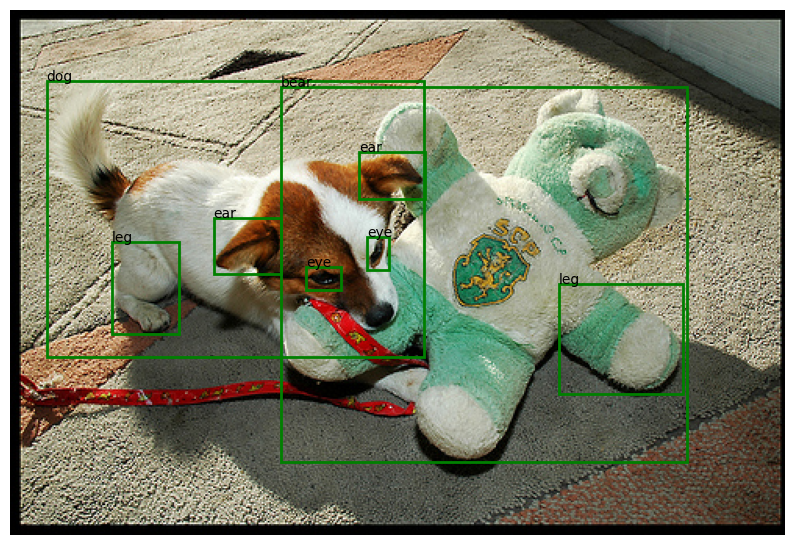

In [43]:
# Cell 7: Visualize Detections with Bounding Boxes Only (no masks)

plt.figure(figsize=(10, 10))
plt.imshow(image_np)

for box, label in zip(detections.xyxy, phrases):
    show_box(box, plt.gca(), label)

plt.axis('off')
plt.savefig(os.path.join(output_dir, "detection_output.jpg"), bbox_inches="tight", dpi=300, pad_inches=0.0)